In [1]:
!pip install prophet pandas numpy matplotlib seaborn scikit-learn

In [2]:
from google.colab import files
import pandas as pd

print("A file picker will appear — upload your shipments.csv file")
uploaded = files.upload()

A file picker will appear — upload your shipments.csv file


Saving shipments.csv to shipments.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load the shipments data
df = pd.read_csv('shipments.csv')
df['shipment_date'] = pd.to_datetime(df['shipment_date'])

print(f"Loaded {len(df):,} rows")
print(f"Date range: {df['shipment_date'].min().date()}  →  {df['shipment_date'].max().date()}")

# ── Aggregate to daily level ───────────────────────────────────
# Prophet needs one row per day with:
#   ds = date
#   y  = the value we are forecasting (daily shipment count)

daily = df.groupby('shipment_date').agg(
    total_shipments = ('shipment_date', 'count'),
    total_units     = ('unit_count', 'sum'),
    late_count      = ('status', lambda x: (x == 'late').sum()),
    avg_units       = ('unit_count', 'mean')
).reset_index()

daily.columns = ['ds', 'total_shipments', 'total_units', 'late_count', 'avg_units']
daily['late_rate'] = (daily['late_count'] / daily['total_shipments'] * 100).round(2)
daily = daily.sort_values('ds').reset_index(drop=True)

print(f"\nDaily records: {len(daily)}")
print(f"\nSample:")
print(daily.head(5).to_string())
print(f"\nAvg daily shipments : {daily['total_shipments'].mean():.0f}")
print(f"Max daily shipments : {daily['total_shipments'].max()}")
print(f"Min daily shipments : {daily['total_shipments'].min()}")

Loaded 180,519 rows
Date range: 2015-01-01  →  2018-01-31

Daily records: 1127

Sample:
          ds  total_shipments  total_units  late_count  avg_units  late_rate
0 2015-01-01              168          355          91   2.113095      54.17
1 2015-01-02              154          354          64   2.298701      41.56
2 2015-01-03              179          392         105   2.189944      58.66
3 2015-01-04              191          410         100   2.146597      52.36
4 2015-01-05              160          373          95   2.331250      59.38

Avg daily shipments : 160
Max daily shipments : 220
Min daily shipments : 68


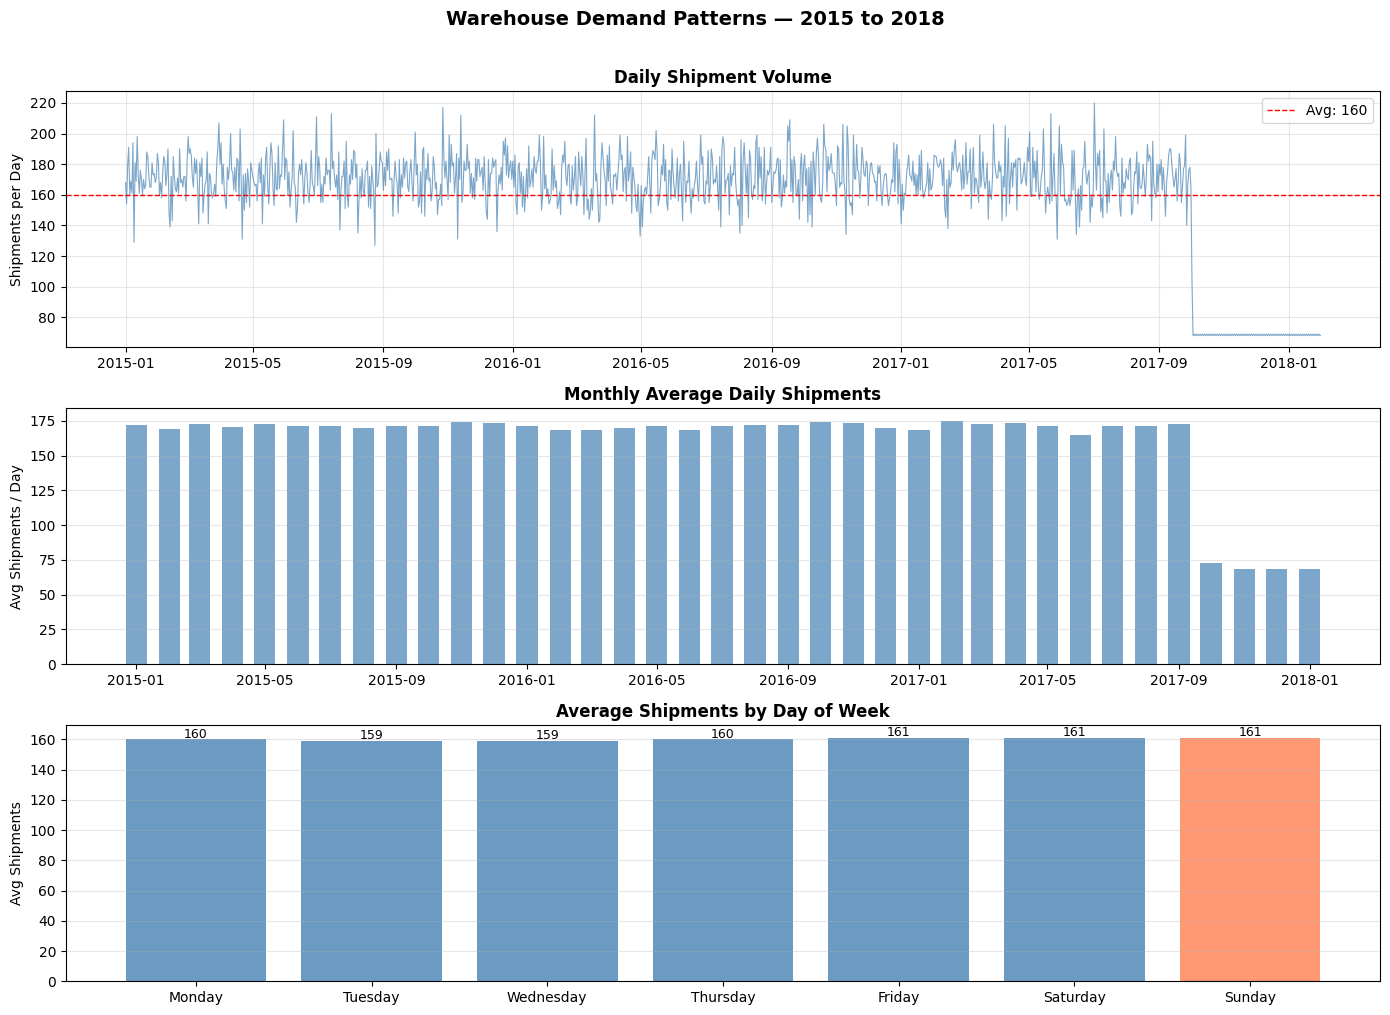

✅ Charts saved as demand_patterns.png


In [4]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Warehouse Demand Patterns — 2015 to 2018',
             fontsize=14, fontweight='bold', y=1.01)

# ── Chart 1: Daily shipment volume over time ──────────────────
axes[0].plot(daily['ds'], daily['total_shipments'],
             color='steelblue', linewidth=0.8, alpha=0.7)
axes[0].set_title('Daily Shipment Volume', fontweight='bold')
axes[0].set_ylabel('Shipments per Day')
axes[0].axhline(daily['total_shipments'].mean(),
                color='red', linestyle='--', linewidth=1,
                label=f"Avg: {daily['total_shipments'].mean():.0f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Chart 2: Monthly average volume ───────────────────────────
monthly = daily.copy()
monthly['month'] = daily['ds'].dt.to_period('M')
monthly_avg = monthly.groupby('month')['total_shipments'].mean().reset_index()
monthly_avg['month_dt'] = monthly_avg['month'].dt.to_timestamp()

axes[1].bar(monthly_avg['month_dt'], monthly_avg['total_shipments'],
            color='steelblue', alpha=0.7, width=20)
axes[1].set_title('Monthly Average Daily Shipments', fontweight='bold')
axes[1].set_ylabel('Avg Shipments / Day')
axes[1].grid(True, alpha=0.3, axis='y')

# ── Chart 3: Day of week pattern ──────────────────────────────
daily['dow'] = daily['ds'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_avg = daily.groupby('dow')['total_shipments'].mean().reindex(dow_order)

colors = ['steelblue' if d != 'Sunday' else 'coral' for d in dow_order]
axes[2].bar(dow_order, dow_avg.values, color=colors, alpha=0.8)
axes[2].set_title('Average Shipments by Day of Week', fontweight='bold')
axes[2].set_ylabel('Avg Shipments')
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(dow_avg.values):
    axes[2].text(i, v + 1, f'{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('demand_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Charts saved as demand_patterns.png")

In [5]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Step 1: Use only clean data (before the 2017 data drop) ──
df_model = daily[daily['ds'] < '2017-10-01'].copy()
df_model = df_model[['ds', 'total_shipments']].rename(
    columns={'total_shipments': 'y'}
)

print(f"Training data : {len(df_model)} days")
print(f"Period        : {df_model['ds'].min().date()}  →  {df_model['ds'].max().date()}")
print(f"Avg daily vol : {df_model['y'].mean():.1f}")

# ── Step 2: Split into train and test ─────────────────────────
# Train on first 80%, test on last 20%
split_idx  = int(len(df_model) * 0.8)
train      = df_model.iloc[:split_idx]
test       = df_model.iloc[split_idx:]

print(f"\nTrain : {len(train)} days  ({train['ds'].min().date()} → {train['ds'].max().date()})")
print(f"Test  : {len(test)} days  ({test['ds'].min().date()} → {test['ds'].max().date()})")

# ── Step 3: Build and train Prophet ───────────────────────────
model = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = True,
    daily_seasonality   = False,
    seasonality_mode    = 'additive',
    changepoint_prior_scale = 0.05,   # controls trend flexibility
    interval_width      = 0.95         # 95% confidence interval
)

model.fit(train)
print("\n✅ Prophet model trained successfully")

Training data : 1004 days
Period        : 2015-01-01  →  2017-09-30
Avg daily vol : 171.3

Train : 803 days  (2015-01-01 → 2017-03-13)
Test  : 201 days  (2017-03-14 → 2017-09-30)

✅ Prophet model trained successfully


   DEMAND FORECAST — MODEL ACCURACY
   MAE  (Mean Absolute Error)  : 12.3 shipments/day
   RMSE (Root Mean Sq Error)   : 15.7 shipments/day
   MAPE (Mean Abs % Error)     : 7.3%
   Accuracy                    : 92.7%


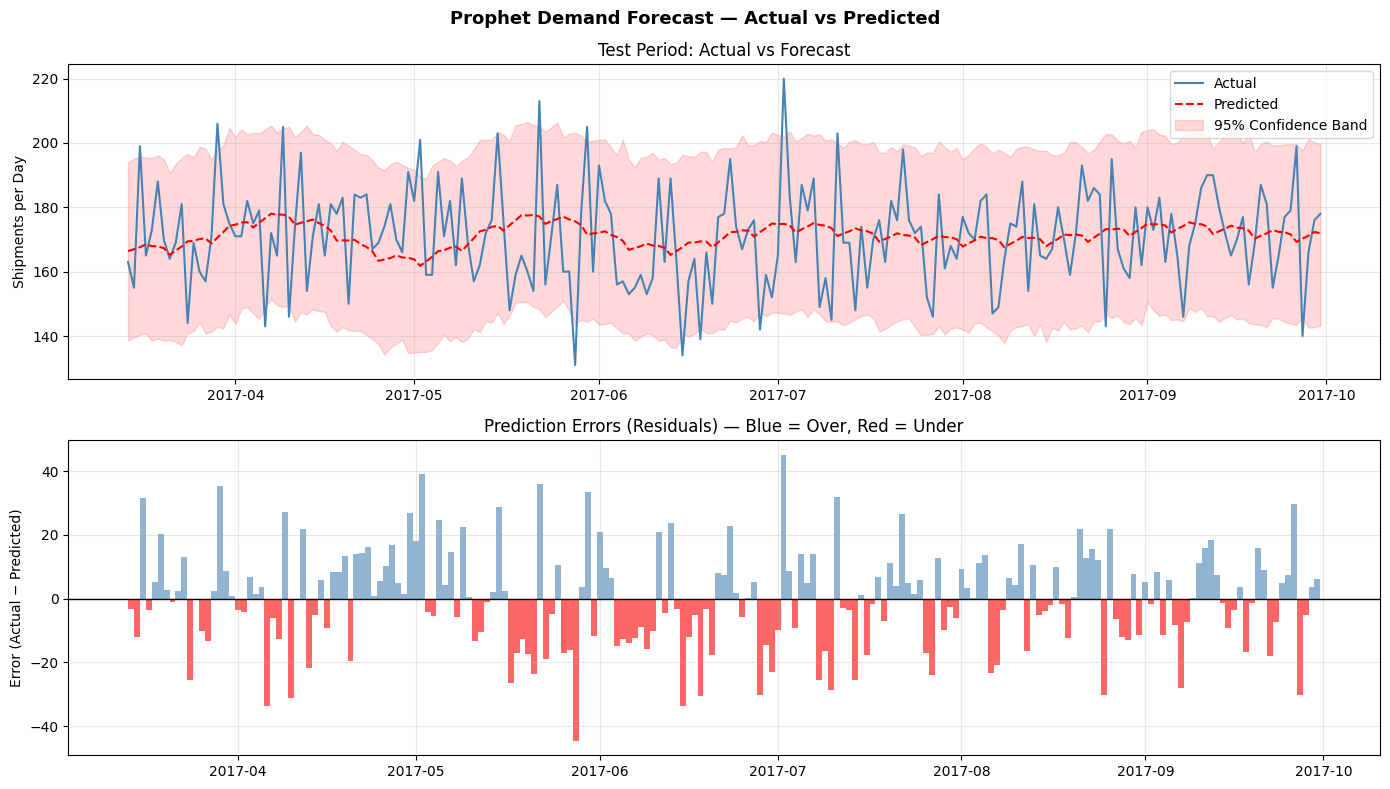


✅ Forecast evaluation complete

Business interpretation:
   On average, our model is off by 12.3 shipments per day
   That means staffing recommendations will be accurate to ±12 shipments
   At avg 171 shipments/day, this is a 7.3% error rate


In [6]:
# ── Step 1: Make predictions on the test period ───────────────
test_forecast = model.predict(test[['ds']])

# ── Step 2: Merge actual vs predicted ─────────────────────────
results = test.merge(
    test_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds'
)

# ── Step 3: Calculate accuracy metrics ───────────────────────
mae  = mean_absolute_error(results['y'], results['yhat'])
rmse = mean_squared_error(results['y'], results['yhat']) ** 0.5
mape = (abs(results['y'] - results['yhat']) / results['y']).mean() * 100

print("=" * 45)
print("   DEMAND FORECAST — MODEL ACCURACY")
print("=" * 45)
print(f"   MAE  (Mean Absolute Error)  : {mae:.1f} shipments/day")
print(f"   RMSE (Root Mean Sq Error)   : {rmse:.1f} shipments/day")
print(f"   MAPE (Mean Abs % Error)     : {mape:.1f}%")
print(f"   Accuracy                    : {100 - mape:.1f}%")
print("=" * 45)

# ── Step 4: Plot actual vs predicted ─────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Prophet Demand Forecast — Actual vs Predicted',
             fontsize=13, fontweight='bold')

# Full test period
axes[0].plot(results['ds'], results['y'],
             label='Actual', color='steelblue', linewidth=1.5)
axes[0].plot(results['ds'], results['yhat'],
             label='Predicted', color='red', linewidth=1.5, linestyle='--')
axes[0].fill_between(results['ds'],
                     results['yhat_lower'], results['yhat_upper'],
                     alpha=0.15, color='red', label='95% Confidence Band')
axes[0].set_title('Test Period: Actual vs Forecast')
axes[0].set_ylabel('Shipments per Day')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals (prediction errors)
residuals = results['y'] - results['yhat']
axes[1].bar(results['ds'], residuals,
            color=['red' if r < 0 else 'steelblue' for r in residuals],
            alpha=0.6, width=1)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Prediction Errors (Residuals) — Blue = Over, Red = Under')
axes[1].set_ylabel('Error (Actual − Predicted)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('forecast_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Forecast evaluation complete")
print(f"\nBusiness interpretation:")
print(f"   On average, our model is off by {mae:.1f} shipments per day")
print(f"   That means staffing recommendations will be accurate to ±{mae:.0f} shipments")
print(f"   At avg {results['y'].mean():.0f} shipments/day, this is a {mape:.1f}% error rate")

Cell 7 — 30-Day Forward Forecast

In [8]:
# ── Fix: use last training date as the reference ──────────────
last_train_date = train['ds'].max()
print(f"Last training date : {last_train_date.date()}")

# Generate future dataframe
future   = model.make_future_dataframe(periods=30, freq='D')
forecast = model.predict(future)

# Get the 30 days immediately after training ended
future_only = forecast[forecast['ds'] > last_train_date].head(30).copy()
future_only = future_only[['ds','yhat','yhat_lower','yhat_upper']].reset_index(drop=True)

future_only['yhat']       = future_only['yhat'].clip(lower=50).round(0).astype(int)
future_only['yhat_lower'] = future_only['yhat_lower'].clip(lower=0).round(0).astype(int)
future_only['yhat_upper'] = future_only['yhat_upper'].clip(lower=0).round(0).astype(int)
future_only['day_name']   = future_only['ds'].dt.day_name()

print("\n30-DAY DEMAND FORECAST")
print("=" * 62)
print(f"{'Date':<14} {'Day':<12} {'Low':<8} {'Forecast':<12} {'High':<8}")
print("-" * 62)
for _, row in future_only.iterrows():
    print(f"{str(row['ds'].date()):<14} {row['day_name']:<12} "
          f"{row['yhat_lower']:<8} {row['yhat']:<12} {row['yhat_upper']:<8}")
print("=" * 62)
print(f"\nAvg forecasted daily volume : {future_only['yhat'].mean():.0f} shipments")
print(f"Peak day forecast           : {future_only['yhat'].max()} shipments")
print(f"Lowest day forecast         : {future_only['yhat'].min()} shipments")

Last training date : 2017-03-13

30-DAY DEMAND FORECAST
Date           Day          Low      Forecast     High    
--------------------------------------------------------------
2017-03-14     Tuesday      139      166          194     
2017-03-15     Wednesday    140      167          195     
2017-03-16     Thursday     139      168          197     
2017-03-17     Friday       142      169          197     
2017-03-18     Saturday     139      168          196     
2017-03-19     Sunday       141      168          198     
2017-03-20     Monday       138      167          194     
2017-03-21     Tuesday      138      165          194     
2017-03-22     Wednesday    139      167          193     
2017-03-23     Thursday     140      168          197     
2017-03-24     Friday       140      169          196     
2017-03-25     Saturday     142      170          196     
2017-03-26     Sunday       143      170          197     
2017-03-27     Monday       141      170          199  

In [9]:
# ── Staffing Logic ─────────────────────────────────────────────
# Based on our data analysis:
#   Morning shift handles ~50% of daily volume
#   Afternoon shift handles ~30%
#   Night shift handles ~20%
#   Productivity benchmark = 22 units per worker per hour
#   Shift duration = 8 hours

PRODUCTIVITY    = 22    # units per worker per hour
SHIFT_HOURS     = 8     # hours per shift
SAFETY_BUFFER   = 1.10  # add 10% extra as buffer

SHIFT_SPLIT = {
    'morning'  : 0.50,
    'afternoon': 0.30,
    'night'    : 0.20
}

def recommend_staff(forecasted_shipments, avg_units_per_shipment=2.2):
    total_units = forecasted_shipments * avg_units_per_shipment
    recommendations = {}

    for shift, pct in SHIFT_SPLIT.items():
        shift_units   = total_units * pct
        raw_workers   = shift_units / (PRODUCTIVITY * SHIFT_HOURS)
        final_workers = max(8, int(raw_workers * SAFETY_BUFFER) + 1)

        recommendations[shift] = {
            'units_to_process' : int(shift_units),
            'recommended_staff': final_workers,
            'forklift_ops'     : max(2, final_workers // 5),
            'pickers_sorters'  : max(3, int(final_workers * 0.50)),
            'loaders'          : max(2, int(final_workers * 0.30)),
            'supervisors'      : max(1, final_workers // 10)
        }

    return recommendations

# ── Apply to every day in the 30-day forecast ─────────────────
print("30-DAY STAFFING RECOMMENDATION PLAN")
print("=" * 75)
print(f"{'Date':<13} {'Day':<11} {'Forecast':<10} "
      f"{'Morning':<10} {'Afternoon':<11} {'Night':<8} {'Total'}")
print("-" * 75)

schedule_rows = []
for _, row in future_only.iterrows():
    recs        = recommend_staff(row['yhat'])
    morning_n   = recs['morning']['recommended_staff']
    afternoon_n = recs['afternoon']['recommended_staff']
    night_n     = recs['night']['recommended_staff']
    total       = morning_n + afternoon_n + night_n

    print(f"{str(row['ds'].date()):<13} {row['day_name']:<11} "
          f"{row['yhat']:<10} {morning_n:<10} {afternoon_n:<11} "
          f"{night_n:<8} {total}")

    schedule_rows.append({
        'date'         : row['ds'].date(),
        'day'          : row['day_name'],
        'forecast_vol' : row['yhat'],
        'morning_staff': morning_n,
        'afternoon_staff': afternoon_n,
        'night_staff'  : night_n,
        'total_staff'  : total
    })

print("=" * 75)

schedule_df = pd.DataFrame(schedule_rows)

print(f"\nAvg total workers per day : {schedule_df['total_staff'].mean():.0f}")
print(f"Peak staffing day         : {schedule_df.loc[schedule_df['total_staff'].idxmax(), 'date']}  ({schedule_df['total_staff'].max()} workers)")
print(f"Lightest staffing day     : {schedule_df.loc[schedule_df['total_staff'].idxmin(), 'date']}  ({schedule_df['total_staff'].min()} workers)")

# ── Show detailed breakdown for Day 1 ────────────────────────
first_day  = future_only.iloc[0]
first_recs = recommend_staff(first_day['yhat'])

print(f"\n── Detailed Role Breakdown for {str(first_day['ds'].date())} ──")
print(f"   Forecasted volume : {first_day['yhat']} shipments")
for shift, details in first_recs.items():
    print(f"\n   {shift.upper()} SHIFT:")
    print(f"     Units to process   : {details['units_to_process']}")
    print(f"     Total workers      : {details['recommended_staff']}")
    print(f"     Forklift operators : {details['forklift_ops']}")
    print(f"     Pickers/Sorters    : {details['pickers_sorters']}")
    print(f"     Loaders            : {details['loaders']}")
    print(f"     Supervisors        : {details['supervisors']}")

30-DAY STAFFING RECOMMENDATION PLAN
Date          Day         Forecast   Morning    Afternoon   Night    Total
---------------------------------------------------------------------------
2017-03-14    Tuesday     166        8          8           8        24
2017-03-15    Wednesday   167        8          8           8        24
2017-03-16    Thursday    168        8          8           8        24
2017-03-17    Friday      169        8          8           8        24
2017-03-18    Saturday    168        8          8           8        24
2017-03-19    Sunday      168        8          8           8        24
2017-03-20    Monday      167        8          8           8        24
2017-03-21    Tuesday     165        8          8           8        24
2017-03-22    Wednesday   167        8          8           8        24
2017-03-23    Thursday    168        8          8           8        24
2017-03-24    Friday      169        8          8           8        24
2017-03-25    Saturda

✅ Files saved:
   30day_staffing_plan.csv   — staffing recommendations
   30day_demand_forecast.csv — raw forecast numbers
   model_summary.csv         — model performance metrics


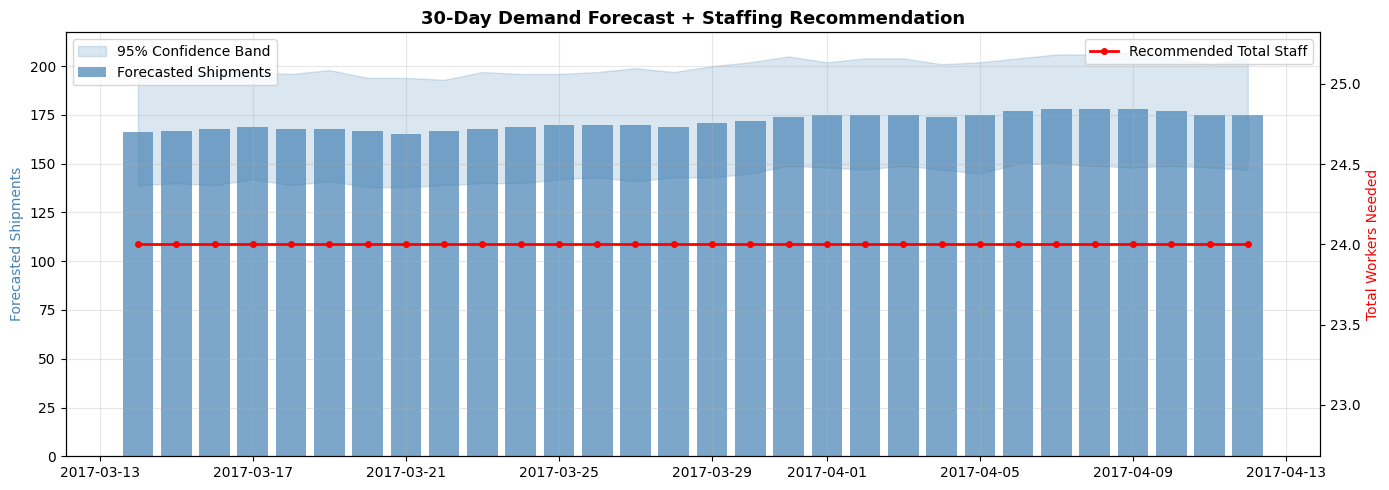


✅ Model 1 (Demand Forecasting) COMPLETE

What we built:
  → Prophet time-series model trained on 803 days of data
  → 30-day shipment volume forecast with confidence bands
  → Automated staffing recommendation engine
  → Role-level breakdown per shift (forklift, pickers, loaders)


In [10]:
# ── Save all outputs ───────────────────────────────────────────
schedule_df.to_csv('30day_staffing_plan.csv', index=False)
future_only.to_csv('30day_demand_forecast.csv', index=False)

# ── Save model summary ─────────────────────────────────────────
summary = {
    'metric': ['MAE', 'RMSE', 'MAPE', 'Accuracy',
               'Training Days', 'Forecast Horizon',
               'Avg Forecasted Volume', 'Avg Daily Staff Needed'],
    'value': [
        f"{mae:.1f} shipments/day",
        f"{rmse:.1f} shipments/day",
        f"{mape:.1f}%",
        f"{100 - mape:.1f}%",
        f"{len(train)} days",
        "30 days",
        f"{future_only['yhat'].mean():.0f} shipments/day",
        f"{schedule_df['total_staff'].mean():.0f} workers/day"
    ]
}
summary_df = pd.DataFrame(summary)
summary_df.to_csv('model_summary.csv', index=False)

print("✅ Files saved:")
print("   30day_staffing_plan.csv   — staffing recommendations")
print("   30day_demand_forecast.csv — raw forecast numbers")
print("   model_summary.csv         — model performance metrics")

# ── Final forecast chart ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(future_only['ds'], future_only['yhat'],
       color='steelblue', alpha=0.7, label='Forecasted Shipments')
ax.fill_between(future_only['ds'],
                future_only['yhat_lower'],
                future_only['yhat_upper'],
                alpha=0.2, color='steelblue', label='95% Confidence Band')

ax2 = ax.twinx()
ax2.plot(schedule_df['date'],
         schedule_df['total_staff'],
         color='red', linewidth=2,
         marker='o', markersize=4,
         label='Recommended Total Staff')

ax.set_title('30-Day Demand Forecast + Staffing Recommendation',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Forecasted Shipments', color='steelblue')
ax2.set_ylabel('Total Workers Needed', color='red')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('staffing_forecast_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Model 1 (Demand Forecasting) COMPLETE")
print("\nWhat we built:")
print("  → Prophet time-series model trained on 803 days of data")
print("  → 30-day shipment volume forecast with confidence bands")
print("  → Automated staffing recommendation engine")
print("  → Role-level breakdown per shift (forklift, pickers, loaders)")

In [11]:
from google.colab import files

files.download('30day_staffing_plan.csv')
files.download('30day_demand_forecast.csv')
files.download('model_summary.csv')
files.download('demand_patterns.png')
files.download('forecast_accuracy.png')
files.download('staffing_forecast_chart.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
from google.colab import files

files.download('30day_demand_forecast.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>